# RQ23 — Closed-Loop Recovery / Fresh Retry

**Research question:** Can a fresh independent recognition pass recover a physical failure that static Top-k reuse cannot, and what evidence should trigger that retry?

This notebook is an operational audit of the frozen MAIN v8 closed-loop workflow. It does not retrain MAIN v8 and does not tune the 0.20 retry threshold.

The frozen evidence set contains six automatic-recognition sessions with post-hoc ground truth. W3 remains a physical unlock problem; the static Top-k analysis therefore concerns only W1, W2 and W4.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path
import importlib
import sys
import pandas as pd

MYDRIVE = Path('/content/drive/MyDrive')

candidates = [
    MYDRIVE / 'Padlock_Reproduction_v1' / 'results' / '23_RQ23_Closed_Loop_Recovery',
    MYDRIVE / 'Padlock_Reproduction_v1' / 'Padlock_Reproduction_v1' / 'results' / '23_RQ23_Closed_Loop_Recovery',
]
RESULT_DIR = next((p for p in candidates if p.is_dir()), None)
if RESULT_DIR is None:
    matches = [p for p in MYDRIVE.rglob('23_RQ23_Closed_Loop_Recovery') if p.is_dir()]
    if len(matches) != 1:
        raise FileNotFoundError(f'Could not uniquely locate RQ23 result folder: {matches}')
    RESULT_DIR = matches[0]

sys.path.insert(0, str(RESULT_DIR))
import RQ23_closed_loop_recovery as rq23
rq23 = importlib.reload(rq23)

RECOGNITION_ROOT = rq23.locate_recognition_root(MYDRIVE)

print('RQ23 result folder:', RESULT_DIR)
print('Recognition source:', RECOGNITION_ROOT)
print('Frozen sessions:', rq23.SESSION_IDS)
print('Retry threshold:', rq23.RETRY_MARGIN_THRESHOLD)

Mounted at /content/drive
RQ23 result folder: /content/drive/MyDrive/Padlock_Reproduction_v1/results/23_RQ23_Closed_Loop_Recovery
Recognition source: /content/drive/MyDrive/dataset/recognition_results
Frozen sessions: ['AUTO_2475_01', 'AUTO_3159_01', 'AUTO_5318_01', 'AUTO_6924_01', 'AUTO_7642_01', 'AUTO_9086_01']
Retry threshold: 0.2


## Source check

Each frozen session must contain its saved flow report. Candidate-evidence CSVs are used when present to recover the exact fused rank of the post-hoc true digit.

In [2]:
source_rows = []
for session in rq23.SESSION_IDS:
    session_dir = RECOGNITION_ROOT / session
    source_rows.append({
        'session': session,
        'flow_report': (session_dir / 'AUTO_flow_report.txt').exists(),
        'candidate_evidence': (session_dir / 'MAIN_v8_candidate_evidence.csv').exists(),
    })

source_check = pd.DataFrame(source_rows)
display(source_check)
assert len(source_check) == 6
assert source_check['flow_report'].all()
print('RQ23 source check passed.')

,session,flow_report,candidate_evidence
0,AUTO_2475_01,True,True
1,AUTO_3159_01,True,True
2,AUTO_5318_01,True,True
3,AUTO_6924_01,True,True
4,AUTO_7642_01,True,True
5,AUTO_9086_01,True,True


RQ23 source check passed.


## Reconstruct the closed-loop sessions

The flow reports provide physical outcome, pass count, start/end code, Top-3 lists and margins. Post-hoc true codes are used only for evaluation. Where candidate evidence is present, exact true-digit fused ranks are recovered from the saved MAIN v8 output.

In [3]:
session_summary, pass_detail, metrics, recovery_cases = rq23.analyse_recognition_sessions(
    recognition_root=RECOGNITION_ROOT,
    result_dir=RESULT_DIR,
)

show_cols = [
    'session', 'true_code', 'pass1_start_code', 'pass1_end_code',
    'pass1_outcome', 'pass1_minimum_margin',
    'W1_true_rank', 'W2_true_rank', 'W4_true_rank',
    'static_top2_prefix_covered', 'static_top3_prefix_covered',
    'passes_used', 'final_physical_unlock', 'final_end_code',
]
display(session_summary[show_cols].style.format({'pass1_minimum_margin': '{:.3f}'}))
display(metrics)

assert len(session_summary) == 6
assert int(session_summary['pass1_physical_unlock'].sum()) == 5
assert int(session_summary['final_physical_unlock'].sum()) == 6
assert len(recovery_cases) == 1
print('Closed-loop session reconstruction passed.')

,session,true_code,pass1_start_code,pass1_end_code,pass1_outcome,pass1_minimum_margin,W1_true_rank,W2_true_rank,W4_true_rank,static_top2_prefix_covered,static_top3_prefix_covered,passes_used,final_physical_unlock,final_end_code
0,AUTO_2475_01,2475,5636,2475,UNLOCKED_TOP1,0.174,1.000000,1.000000,1.000000,True,True,1,True,2475
1,AUTO_3159_01,3159,6786,3159,UNLOCKED_TOP1,0.574,1.000000,1.000000,1.000000,True,True,1,True,3159
2,AUTO_5318_01,5318,3457,5318,UNLOCKED_TOP1,0.557,1.000000,1.000000,1.000000,True,True,1,True,5318
3,AUTO_6924_01,6924,3245,6246,TOP1_NO_UNLOCK_LOW_MARGIN,0.070,1.000000,4.000000,2.000000,False,False,2,True,6924
5,AUTO_7642_01,7642,3658,7642,UNLOCKED_TOP1,0.574,1.000000,1.000000,1.000000,True,True,1,True,7642
6,AUTO_9086_01,9086,2134,9086,UNLOCKED_TOP1,0.400,1.000000,1.000000,1.000000,True,True,1,True,9086


,metric,value
0,n_sessions,6.000000
1,first_pass_unlocks,5.000000
2,first_pass_unlock_rate,0.833333
3,final_unlocks,6.000000
4,final_unlock_rate,1.000000
5,first_pass_failures,1.000000
6,low_margin_first_passes,2.000000
7,fresh_retry_eligible_failures,1.000000
8,fresh_retry_rescues,1.000000
9,failed_pass_static_top2_coverage,0.000000


Closed-loop session reconstruction passed.


## Critical recovery case: 6924

The failed first pass is checked against the original static ranking before the fresh observation is considered. This prevents the second pass from being used to redefine whether the first pass was recoverable by Top-k.

In [4]:
case = recovery_cases.iloc[0]
display(recovery_cases)

assert case['session'] == 'AUTO_6924_01'
assert int(case['W1_true_rank']) == 1
assert int(case['W2_true_rank']) == 4
assert int(case['W4_true_rank']) == 2
assert not bool(case['static_top2_prefix_covered'])
assert not bool(case['static_top3_prefix_covered'])
assert bool(case['fresh_retry_unlock'])
assert str(case['pass2_start_code']) == '4760'
assert str(case['pass2_end_code']) == '6924'

print('6924 recovery audit passed: W2 true digit was rank 4 on pass 1, outside Top-2 and Top-3; Fresh Retry unlocked on pass 2.')

,session,true_code,pass1_minimum_margin,W1_true_rank,W2_true_rank,W4_true_rank,static_top2_prefix_covered,static_top3_prefix_covered,fresh_retry_eligible,fresh_retry_used,fresh_retry_unlock,pass2_start_code,pass2_end_code,pass2_minimum_margin
0,AUTO_6924_01,6924,0.069631,1.0,4.0,2.0,False,False,True,True,True,4760,6924,0.382971


6924 recovery audit passed: W2 true digit was rank 4 on pass 1, outside Top-2 and Top-3; Fresh Retry unlocked on pass 2.


## Why margin alone is not the failure detector

The operational rule is intentionally `physical failure AND low margin`, not simply `margin < 0.20`. The 2475 session provides the counterexample: its first-pass minimum margin is below 0.20, but the lock opens correctly on that same pass.

In [5]:
margin_check = session_summary[[
    'session', 'true_code', 'pass1_minimum_margin',
    'pass1_low_margin', 'pass1_physical_unlock', 'pass1_fresh_retry_eligible'
]].copy()

display(margin_check.style.format({'pass1_minimum_margin': '{:.3f}'}))

row_2475 = margin_check[margin_check['session'] == 'AUTO_2475_01'].iloc[0]
assert row_2475['pass1_minimum_margin'] < 0.20
assert bool(row_2475['pass1_physical_unlock'])
assert not bool(row_2475['pass1_fresh_retry_eligible'])
print('Margin-gating check passed.')

,session,true_code,pass1_minimum_margin,pass1_low_margin,pass1_physical_unlock,pass1_fresh_retry_eligible
0,AUTO_2475_01,2475,0.174,True,True,False
1,AUTO_3159_01,3159,0.574,False,True,False
2,AUTO_5318_01,5318,0.557,False,True,False
3,AUTO_6924_01,6924,0.070,True,False,True
5,AUTO_7642_01,7642,0.574,False,True,False
6,AUTO_9086_01,9086,0.400,False,True,False


Margin-gating check passed.


## Final figures

The figures are deliberately simple. The second figure is explicitly an observed single-failure case study, not a population estimate.

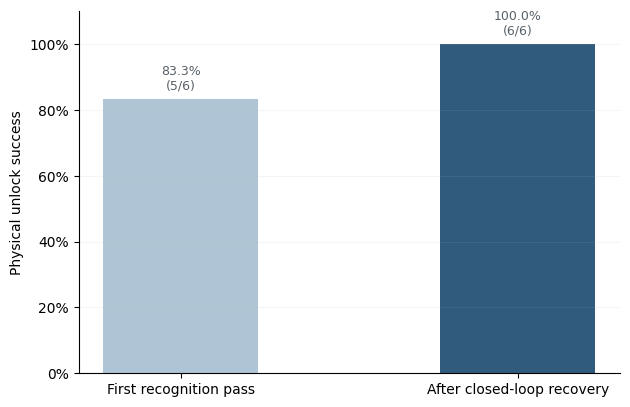

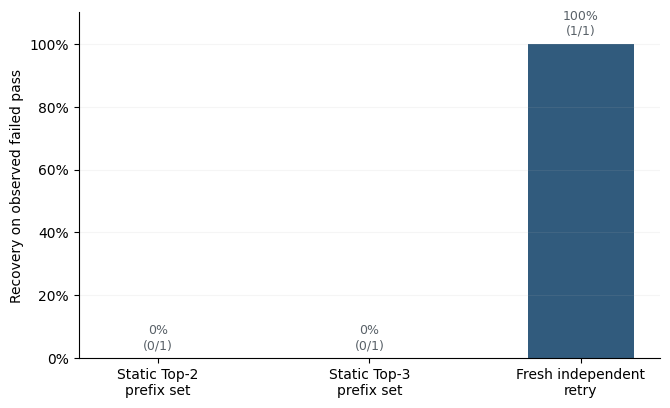

RQ23 figures saved.


In [6]:
rq23.save_figures(
    session_summary=session_summary,
    recovery_df=recovery_cases,
    result_dir=RESULT_DIR,
)
print('RQ23 figures saved.')

## Report and frozen conclusion

In [7]:
report_path = rq23.write_report(
    session_summary=session_summary,
    pass_df=pass_detail,
    recovery_df=recovery_cases,
    result_dir=RESULT_DIR,
)

print('Report:', report_path)
print('Saved outputs:')
for path in sorted(RESULT_DIR.glob('RQ23_*')):
    print(' ', path.name)

Report: /content/drive/MyDrive/Padlock_Reproduction_v1/results/23_RQ23_Closed_Loop_Recovery/RQ23_Report.md
Saved outputs:
  RQ23_Fig1_Closed_Loop_Success.pdf
  RQ23_Fig1_Closed_Loop_Success.png
  RQ23_Fig2_Observed_Recovery_Strategies.pdf
  RQ23_Fig2_Observed_Recovery_Strategies.png
  RQ23_Metrics.csv
  RQ23_Pass_Detail.csv
  RQ23_Protocol.md
  RQ23_Recovery_Cases.csv
  RQ23_Report.md
  RQ23_Session_Summary.csv
  RQ23_closed_loop_recovery.py
  RQ23_conclusion.json
  RQ23_run_info.json
